# eval DB viewer

Read-only look at the two shared SQLite DBs.

- **records (ops DB)** `easyads_ops.db` — jobs / node_executions / llm_calls / schema_validations / job_cost_summary / dirty_field_events
- **eval DB** `easyads_eval.db` — eval_runs / score_items / gate_results / domain_scores / judge_status

Run the **Setup** cell first, then any cell below. Re-run a cell to refresh (safe to run while `make eval-sample` is generating).

**Validity rule:** a job is real only if every `llm_calls.fallback_used = 0` AND `t2i_engine = gpt_image_2` AND `imgs >= 1`. Any `fallback_used = 1` -> discard that job.

## Setup

In [47]:
import os, sqlite3

# polars(빠른 Rust DataFrame)로 표시. 미설치 환경(호스트 .venv 등)에선 stdlib _Table 폴백 →
# 노트북이 어디서든 hard-fail 안 함. 컨테이너(Dockerfile.eval)엔 polars 포함.
try:
    import polars as pl
    pl.Config.set_tbl_rows(-1)
    pl.Config.set_tbl_cols(-1)
    pl.Config.set_tbl_width_chars(10000)
    pl.Config.set_fmt_str_lengths(150)
    _HAVE_POLARS = True
except ModuleNotFoundError:
    _HAVE_POLARS = False


class _Table:
    """polars 미설치용 경량 폴백 — q()와 동일 인터페이스([r, c] 인덱싱, len) 유지해
    아래 셀들의 df[0, 0] / len(df) 가 polars 유무와 무관하게 동작."""
    def __init__(self, columns, rows):
        self.columns, self.rows = columns, rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, key):
        if isinstance(key, tuple):
            r, c = key
            return self.rows[r][c]
        return self.rows[key]
    def __repr__(self):
        if not self.rows:
            return " | ".join(self.columns) + "\n(0 rows)"
        w = [max([len(str(c))] + [len(str(r[i])) for r in self.rows]) for i, c in enumerate(self.columns)]
        head = " | ".join(str(c).ljust(w[i]) for i, c in enumerate(self.columns))
        sep = "-+-".join("-" * x for x in w)
        body = "\n".join(" | ".join(str(v).ljust(w[i]) for i, v in enumerate(r)) for r in self.rows)
        return f"{head}\n{sep}\n{body}"


# /home/records on host, /app/records inside a container. Override with RECORDS_DIR.
RECORDS = os.environ.get('RECORDS_DIR') or next(
    (p for p in ('/home/records', '/app/records') if os.path.isdir(p)), '/home/records')
OPS_DB  = os.path.join(RECORDS, 'easyads_ops.db')
EVAL_DB = os.path.join(RECORDS, 'easyads_eval.db')


def q(db, sql, params=()):
    """읽기전용 쿼리 실행 → polars DataFrame(있으면) 또는 _Table 폴백."""
    with sqlite3.connect(db) as c:
        cur = c.execute(sql, params)
        rows = [tuple(r) for r in cur.fetchall()]
        cols = [d[0] for d in cur.description]
    if _HAVE_POLARS:
        return pl.DataFrame(rows, schema=cols, orient="row") if rows else pl.DataFrame(schema=cols)
    return _Table(cols, rows)


print('polars  :', 'yes' if _HAVE_POLARS else 'NO (stdlib fallback)')
print('RECORDS :', RECORDS)
print('OPS_DB  :', OPS_DB,  '(exists)' if os.path.isfile(OPS_DB)  else '(MISSING)')
print('EVAL_DB :', EVAL_DB, '(exists)' if os.path.isfile(EVAL_DB) else '(MISSING)')

polars  : yes
RECORDS : /app/records
OPS_DB  : /app/records/easyads_ops.db (exists)
EVAL_DB : /app/records/easyads_eval.db (exists)


In [48]:
os.getcwd()

'/app/orchestrator/eval'

# records (ops DB)

### jobs — overview (newest first)

In [49]:
q(OPS_DB, '''
  SELECT job_id, user_plan AS plan, render_profile AS render, status,
         entry_mode, revision, created_at
  FROM jobs ORDER BY created_at DESC LIMIT 30
''')

job_id,plan,render,status,entry_mode,revision,created_at
str,str,str,str,str,i64,str
"""test_beauty_reservation_20260608075315""","""free""","""balanced""","""done""","""chat_start""",1,"""2026-06-08T07:57:04.669334+00:00"""
"""test_flower_graduation_discount_20260608075315""","""free""","""balanced""","""done""","""chat_start""",1,"""2026-06-08T07:53:15.327432+00:00"""
"""test_beauty_reservation_20260608073200""","""free""","""balanced""","""input_received""","""chat_start""",1,"""2026-06-08T07:32:21.542604+00:00"""
"""test_flower_graduation_discount_20260608073200""","""free""","""balanced""","""input_received""","""chat_start""",1,"""2026-06-08T07:32:00.362933+00:00"""
"""test_bespoke_bridal_atelier_nearest_20260608072551""","""free""","""balanced""","""input_received""","""chat_start""",1,"""2026-06-08T07:25:52.155018+00:00"""
"""test_restaurant_custom_copy_20260608072551""","""free""","""balanced""","""input_received""","""chat_start""",1,"""2026-06-08T07:25:51.644150+00:00"""
"""test_cafe_explicit_injection_20260608070815""","""free""","""fast""","""done""","""chat_start""",1,"""2026-06-08T07:08:15.166095+00:00"""
"""test_premium_kitchen_showroom_20260608070256""","""free""","""fast""","""done""","""chat_start""",1,"""2026-06-08T07:02:56.917490+00:00"""
"""test_adult_goods_store_20260608063943""","""free""","""fast""","""done""","""chat_start""",1,"""2026-06-08T06:39:43.442994+00:00"""


### llm_calls — fallback summary per job (fb_total must be 0 for a valid run)

In [50]:
q(OPS_DB, '''
  SELECT job_id,
         COUNT(*)            AS llm_calls,
         SUM(fallback_used)  AS fb_total,
         SUM(success)        AS ok_total,
         GROUP_CONCAT(DISTINCT error_code) AS errors
  FROM llm_calls GROUP BY job_id ORDER BY job_id DESC LIMIT 30
''')

job_id,llm_calls,fb_total,ok_total,errors
str,i64,i64,i64,str
"""test_store_yearend_gift_20260607192552""",2,2,0,"""free_plan_deterministic_fallback"""
"""test_restaurant_custom_copy_20260608072551""",1,1,0,"""free_plan_deterministic_fallback"""
"""test_premium_kitchen_showroom_20260608070256""",2,2,0,"""llm_api_error:APITimeoutError,free_plan_deterministic_fallback"""
"""test_flower_graduation_discount_20260608075315""",2,1,1,"""free_plan_deterministic_fallback"""
"""test_flower_graduation_discount_20260608073200""",2,1,1,"""free_plan_deterministic_fallback"""
"""test_fitness_free_trial_20260607173418""",4,0,4,null
"""test_cafe_morning_set_20260608011644""",4,0,4,null
"""test_cafe_iced_americano_20260608000015""",2,2,0,"""free_plan_deterministic_fallback"""
"""test_cafe_explicit_injection_20260608070815""",2,1,1,"""free_plan_deterministic_fallback"""


### llm_calls — per-node detail (model / fallback / error / cost)

In [51]:
q(OPS_DB, '''
  SELECT job_id, node_name, model_class, model_name,
         success AS ok, fallback_used AS fb,
         COALESCE(error_code,'') AS error_code,
         total_tokens AS tok, cost_usd, cost_source
  FROM llm_calls ORDER BY id DESC LIMIT 60
''')

job_id,node_name,model_class,model_name,ok,fb,error_code,tok,cost_usd,cost_source
str,str,str,str,i64,i64,str,i64,f64,str
"""test_beauty_reservation_20260608075315""","""copy_candidate_generation""","""local_quality""","""gemma4-e4b-gpu""",1,0,"""""",null,0.0,"""self_hosted"""
"""test_beauty_reservation_20260608075315""","""tone_binding""","""mock""","""mock""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""adapter"""
"""test_flower_graduation_discount_20260608075315""","""copy_candidate_generation""","""local_quality""","""gemma4-e4b-gpu""",1,0,"""""",null,0.0,"""self_hosted"""
"""test_flower_graduation_discount_20260608075315""","""tone_binding""","""mock""","""mock""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""adapter"""
"""test_beauty_reservation_20260608073200""","""copy_candidate_generation""","""local_quality""","""gemma4-e4b-gpu""",1,0,"""""",null,0.0,"""self_hosted"""
"""test_beauty_reservation_20260608073200""","""tone_binding""","""mock""","""mock""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""adapter"""
"""test_flower_graduation_discount_20260608073200""","""copy_candidate_generation""","""local_quality""","""gemma4-e4b-gpu""",1,0,"""""",null,0.0,"""self_hosted"""
"""test_flower_graduation_discount_20260608073200""","""tone_binding""","""mock""","""mock""",0,1,"""free_plan_deterministic_fallback""",null,0.0,"""adapter"""
"""test_bespoke_bridal_atelier_nearest_20260608072551""","""copy_candidate_generation""","""local_quality""","""gemma4-e4b-gpu""",1,0,"""""",null,0.0,"""self_hosted"""


### node_executions — status & latency (t2i_generation dominates wall time)

In [52]:
# set a job_id to focus, or leave '' for the latest job
JOB_ID = ''
if not JOB_ID:
    JOB_ID = q(OPS_DB, 'SELECT job_id FROM jobs ORDER BY created_at DESC LIMIT 1')[0, 0]
print('JOB_ID =', JOB_ID)
q(OPS_DB, '''
  SELECT node_name, status, latency_ms AS ms,
         SUBSTR(COALESCE(error_message,''),1,50) AS err
  FROM node_executions WHERE job_id=? ORDER BY id
''', (JOB_ID,))

JOB_ID = test_beauty_reservation_20260608075315


node_name,status,ms,err
str,str,i64,str
"""input""","""completed""",8,""""""
"""validator""","""completed""",4,""""""
"""options""","""started""",null,""""""
"""options""","""completed""",3,""""""
"""state_update""","""completed""",4,""""""
"""validator""","""completed""",3,""""""
"""format_planner""","""completed""",4,""""""
"""tone_binding""","""completed""",11,""""""
"""copy_candidate_generation""","""completed""",100675,""""""


### node_state_outputs — 각 노드가 state에 쓴 내용 (per node)
위 `node_executions`는 status/latency만 보여줌. 이 셀은 각 노드가 실제로 **쓴 필드 수 + 출력 스냅샷**을 함께 표시. 전체 출력은 `show_node('<node_name>')`.

In [53]:
# 각 노드 statement: status + latency + 쓴 필드 수 + snapshot head (JOB_ID 재사용)
state = q(OPS_DB, '''
  SELECT e.node_name, e.status, e.latency_ms AS ms,
         json_array_length(s.fields_written) AS n_fields,
         SUBSTR(s.output_snapshot, 1, 140) AS snapshot_head
  FROM node_executions e
  LEFT JOIN node_state_outputs s ON s.node_exec_id = e.id
  WHERE e.job_id=? ORDER BY e.id
''', (JOB_ID,))
state

node_name,status,ms,n_fields,snapshot_head
str,str,i64,i64,str
"""input""","""completed""",8,92,"""{""schema_version"": ""llm_marketing_v1"", ""job_id"": ""test_beauty_reservation_20260608075315"", ""thread_id"": ""test_beauty_reservation_20260608075"""
"""validator""","""completed""",4,14,"""{""context"": {""business_type"": ""beauty_salon"", ""item_or_service"": null, ""region_type"": null, ""target_persona"": null, ""promotion_goal"": ""reser"""
"""options""","""started""",null,null,null
"""options""","""completed""",3,3,"""{""user_selection"": {""job_id"": ""test_beauty_reservation_20260608075315"", ""thread_id"": ""test_beauty_reservation_20260608075315_thread"", ""field"""
"""state_update""","""completed""",4,6,"""{""context"": {""business_type"": ""beauty_salon"", ""item_or_service"": ""예약 서비스"", ""region_type"": null, ""target_persona"": null, ""promotion_goal"": ""r"""
"""validator""","""completed""",3,14,"""{""context"": {""business_type"": ""beauty_salon"", ""item_or_service"": ""예약 서비스"", ""region_type"": null, ""target_persona"": null, ""promotion_goal"": ""r"""
"""format_planner""","""completed""",4,6,"""{""ad_format_spec"": {""ad_format"": ""instagram_feed"", ""platform"": ""instagram"", ""aspect_ratio"": ""1:1"", ""width"": 1080, ""height"": 1080, ""informati"""
"""tone_binding""","""completed""",11,5,"""{""tone_binding_output"": {""tone_profile"": ""polished_confident"", ""copy_constraints"": [""no_hallucinated_contact"", ""no_unprovided_discount"", ""no"""
"""copy_candidate_generation""","""completed""",100675,8,"""{""copy_candidates"": [{""id"": ""candidate_1"", ""headline"": ""나를 위한 휴식, 지금 예"", ""subcopy"": null, ""cta"": ""예약하고 아름다워지기"", ""hashtags"": [], ""tone_label"""""


#### show_node() 에 넣을 수 있는 노드 이름 목록
marketing 그래프 28노드 (실행된 노드만 DB에 있음). HITL 분기라 job마다 일부만 존재:

| 단계 | 노드 이름 |
|---|---|
| 입력/전처리 | `input` · `reference_template_resolve` · `product_preprocess` · `reference_preprocess` |
| 컨텍스트 | `validator` · `options` · `state_update` |
| 포맷/톤 | `format_planner` · `tone_binding` |
| 카피 | `copy_candidate_generation` · `copy_candidate_selection_interrupt` · `state_update_selected_copy` · `auto_pilot_copywriting` · `custom_copy_input` · `custom_copy_validation` · `no_copy_bypass` |
| 레이아웃 | `copy_spec_parser` · `text_style_binder` · `text_layout_planner` |
| 이미지 프롬프트/T2I | `image_prompt_planner` · `prompt_renderer` · `t2i_request_builder` · `t2i_generation` |
| 배경 검증/수정 | `background_ocr_gate` · `ocr_image_revision` · `background_validation` · `safe_area_gate` |
| 텍스트 렌더/최종 | `text_renderer` · `final_ocr_gate` · `ocr_layout_revision` · `readability_gate` · `final_validation` · `result` |

> 이 job에 실제 존재하는 노드만 보려면:
> `q(OPS_DB, "SELECT DISTINCT node_name FROM node_executions WHERE job_id=? ORDER BY id", (JOB_ID,))`


In [54]:
# 특정 노드 전체 출력 보기 (fields_written + 예쁨 snapshot JSON)
def show_node(node_name, job_id=None):
    jid = job_id or JOB_ID
    with sqlite3.connect(OPS_DB) as c:
        row = c.execute('''
            SELECT s.fields_written, s.output_snapshot
            FROM node_state_outputs s JOIN node_executions e ON s.node_exec_id=e.id
            WHERE e.job_id=? AND s.node_name=? ORDER BY s.id DESC LIMIT 1
        ''', (jid, node_name)).fetchone()
    if not row:
        print(f'no state output for node={node_name!r} job={jid!r}'); return
    fields, snap = row
    import json as _json
    print('fields_written:', ', '.join(_json.loads(fields)))
    print('-' * 60)
    try:
        print(_json.dumps(_json.loads(snap), indent=2, ensure_ascii=False))
    except Exception:
        print(snap)

show_node('image_prompt_planner')

fields_written: image_prompt_spec, image_prompt, current_brief, model_selections, llm_call_results, status
------------------------------------------------------------
{
  "image_prompt_spec": {
    "schema_version": "1.0",
    "scene_description": "clean commercial advertising background for 예약 서비스; soft pastel beauty studio background",
    "product_subject": "예약 서비스",
    "color_palette": [
      "#F8DDE6",
      "#F7F3FF",
      "#C9D7F2"
    ],
    "composition": "minimal elegant product or service mood composition. Reserve a medium clean empty area in the upper right region and a small clean empty area in the lower right region as uncluttered negative space for Korean text overlay in post-processing. Keep those regions calm, simple, and free of visual clutter. Main subject zone: center right service mood.",
    "lighting": "clean bright studio lighting",
    "reserved_text_areas": [
      {
        "x": 0.52,
        "y": 0.12,
        "w": 0.42,
        "h": 0.2
      },
      {

### 프롬프트만 보기 (prompts only)
`show_prompts('<job_id>')` — 그 job이 생성한 **이미지/T2I 프롬프트**만 추출: `image_prompt`(planner), `t2i_request.prompt`(렌더 입력), `prompt_render_output`.
> 주의: LLM 호출의 **raw system/user 프롬프트는 DB에 없음** — `sanitize_metadata()`가 `prompt`/`api_key` 키를 LLMCallResult.metadata에서 제거(불변식). 여기 보이는 건 파이프라인이 만든 *이미지 생성용 프롬프트 텍스트*만.

In [55]:
# 프롬프트 필드만 추출 (이미지 생성 프롬프트 — raw LLM 프롬프트 아님)
def show_prompts(job_id=None):
    import json as _json
    jid = job_id or JOB_ID
    def _snap(node):
        with sqlite3.connect(OPS_DB) as c:
            r = c.execute('''SELECT s.output_snapshot FROM node_state_outputs s
                JOIN node_executions e ON s.node_exec_id=e.id
                WHERE e.job_id=? AND s.node_name=? ORDER BY s.id DESC LIMIT 1''', (jid, node)).fetchone()
        return _json.loads(r[0]) if r and r[0] else {}
    print('JOB_ID =', jid)
    # 1) 최종 T2I 프롬프트 (엔진에 실제 들어간 문자열) — prompt_render_output
    pr = _snap('prompt_renderer').get('prompt_render_output') or {}
    if pr.get('positive_prompt'):
        print('\n[final positive_prompt → %s]' % pr.get('engine','?')); print(pr['positive_prompt'])
    if pr.get('negative_prompt'):
        print('\n[negative_prompt]'); print(pr['negative_prompt'])
    # 2) 구조화 ImagePrompt (planner) — 필드별
    ip = _snap('image_prompt_planner').get('image_prompt') or {}
    if ip:
        print('\n[image_prompt (structured)]')
        for k in ('subject','scene','style','lighting','composition','copy_space','color_palette','avoid_text'):
            if ip.get(k): print(f'  {k}: {ip[k]}')
        if ip.get('negative_prompt'): print(f'  negative_prompt: {ip["negative_prompt"]}')
    # 3) t2i_request negative (planner→request 전달분)
    req = _snap('t2i_request_builder').get('t2i_request') or {}
    if req.get('negative_prompt') and req['negative_prompt'] != pr.get('negative_prompt'):
        print('\n[t2i_request.negative_prompt]'); print(req['negative_prompt'])

show_prompts()

JOB_ID = test_beauty_reservation_20260608075315

[final positive_prompt → sd35_large]
Create a text-free advertising background for later Korean copy overlay. Reserve clean negative space for Korean text overlay in post-processing. Keep reserved text areas uncluttered, smooth, low-detail, and visually calm. Do not include any text, letters, words, numbers, logos, signage, labels, watermark, or typography. premium commercial photography, beauty_hair ad background, 예약 서비스, presented as a clean premium hair styling station with styling chair, large mirror, and styling tools, premium hair salon interior, bright, clean, minimal elegant, clean copy space Additional visual/reference guidance: Reflect this user-selected mood/tone: 감성적인. no readable text. no Korean letters. no logos. no signage. no watermark. no typography. no menu text. no price tags. clean reserved negative space for later copy overlay.

[negative_prompt]
text, letters, words, Korean text, logo, watermark, menu board, label, 

### job_cost_summary — tokens, USD, T2I engine & image cost

In [56]:
q(OPS_DB, '''
  SELECT job_id, total_api_calls AS api, fallback_calls AS fb,
         total_tokens AS tok, total_cost_usd AS usd,
         t2i_engine, t2i_image_count AS imgs, t2i_cost_usd, t2i_cost_source,
         cost_estimated AS est
  FROM job_cost_summary ORDER BY rowid DESC LIMIT 30
''')

job_id,api,fb,tok,usd,t2i_engine,imgs,t2i_cost_usd,t2i_cost_source,est
str,i64,i64,i64,f64,str,i64,f64,str,i64
"""test_beauty_reservation_20260608075315""",0,1,0,0.020662,"""sd35_large""",1,0.020662,"""gpu_exact""",0
"""test_flower_graduation_discount_20260608075315""",0,1,0,0.037577,"""sd35_large""",1,0.037577,"""gpu_exact""",0
"""test_cafe_explicit_injection_20260608070815""",0,1,0,0.0,"""mock""",1,0.0,"""exact""",0
"""test_premium_kitchen_showroom_20260608070256""",0,2,0,0.0,"""mock""",1,0.0,"""exact""",0
"""test_adult_goods_store_20260608063943""",0,2,0,0.0,"""mock""",1,0.0,"""exact""",0
"""test_cafe_morning_set_20260608011644""",4,0,7815,0.074665,"""gpt_image_2""",1,0.04,"""exact""",0
"""test_cafe_iced_americano_20260608000015""",0,2,0,0.019133,"""sd35_large""",1,0.019133,"""gpu_exact""",0
"""test_store_yearend_gift_20260607192552""",0,2,0,0.0,"""sd35_large""",1,null,"""gpu_unpriced""",1
"""test_fitness_free_trial_20260607173418""",4,0,7412,0.029578,"""sd35_large""",1,null,"""gpu_unpriced""",1


### images — generated file paths (result node)

In [57]:
q(OPS_DB, '''
  SELECT ne.job_id,
         json_extract(nso.output_snapshot,'$.result_payload.output_path')           AS final_ad,
         json_extract(nso.output_snapshot,'$.result_payload.background_image_path')  AS background
  FROM node_state_outputs nso
  JOIN node_executions ne ON ne.id = nso.node_exec_id
  WHERE ne.node_name='result'
  GROUP BY ne.job_id ORDER BY ne.id DESC LIMIT 30
''')

job_id,final_ad,background
str,str,str
"""test_beauty_reservation_20260608075315""","""/app/records/images/test_beauty_reservation_20260608075315/final_composite.png""","""/app/records/images/test_beauty_reservation_20260608075315/sd35_large_0.png"""
"""test_flower_graduation_discount_20260608075315""","""/app/records/images/test_flower_graduation_discount_20260608075315/final_composite.png""","""/app/records/images/test_flower_graduation_discount_20260608075315/sd35_large_0.png"""
"""test_cafe_explicit_injection_20260608070815""","""/app/records/images/test_cafe_explicit_injection_20260608070815/final_composite.png""","""/app/records/images/test_cafe_explicit_injection_20260608070815/mock_0.png"""
"""test_premium_kitchen_showroom_20260608070256""","""/app/records/images/test_premium_kitchen_showroom_20260608070256/final_composite.png""","""/app/records/images/test_premium_kitchen_showroom_20260608070256/mock_0.png"""
"""test_adult_goods_store_20260608063943""","""/app/records/images/test_adult_goods_store_20260608063943/final_composite.png""","""/app/records/images/test_adult_goods_store_20260608063943/mock_0.png"""
"""test_cafe_morning_set_20260608011644""","""/app/records/images/test_cafe_morning_set_20260608011644/final_composite.png""","""/app/records/images/test_cafe_morning_set_20260608011644/gpt_image_2_0.png"""
"""test_cafe_iced_americano_20260608000015""","""/app/records/images/test_cafe_iced_americano_20260608000015/final_composite.png""","""/app/records/images/test_cafe_iced_americano_20260608000015/sd35_large_0.png"""
"""test_store_yearend_gift_20260607192552""","""/app/records/images/test_store_yearend_gift_20260607192552/final_composite.png""","""/app/records/images/test_store_yearend_gift_20260607192552/sd35_large_0.png"""
"""test_fitness_free_trial_20260607173418""","""/app/records/images/test_fitness_free_trial_20260607173418/final_composite.png""","""/app/records/images/test_fitness_free_trial_20260607173418/sd35_large_0.png"""


### schema_validations — failures only (empty = all passed)

In [58]:
q(OPS_DB, '''
  SELECT job_id, node_name, schema_name, field_name,
         SUBSTR(COALESCE(error_detail,''),1,80) AS err
  FROM schema_validations WHERE passed=0 ORDER BY id DESC LIMIT 50
''')

job_id,node_name,schema_name,field_name,err
null,null,null,null,null


### preview a generated image (optional)

path: /app/records/images/test_beauty_reservation_20260608075315/final_composite.png


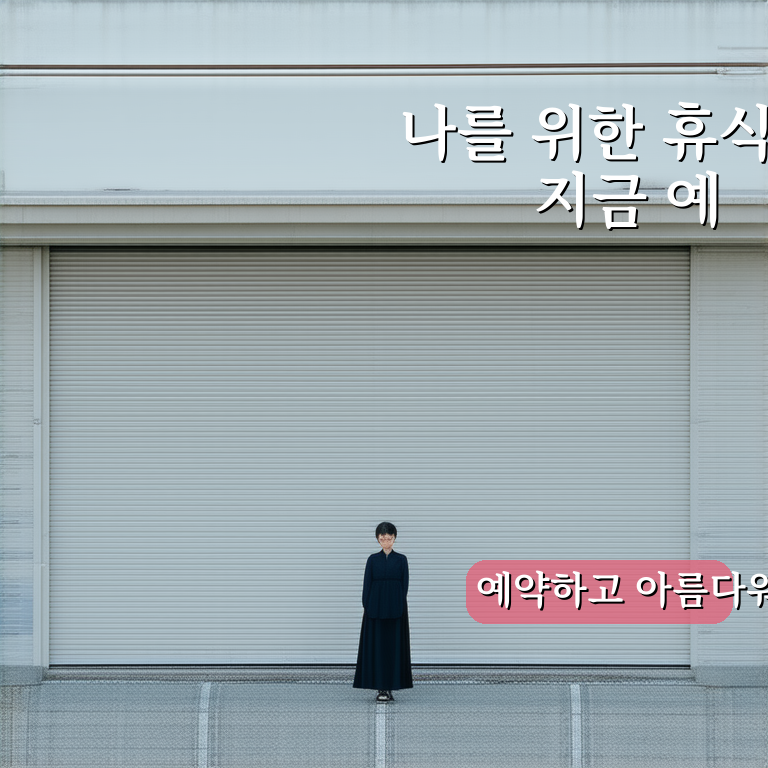

In [59]:
from IPython.display import Image, display
row = q(OPS_DB, '''
  SELECT json_extract(nso.output_snapshot,'$.result_payload.output_path') AS final_ad
  FROM node_state_outputs nso JOIN node_executions ne ON ne.id=nso.node_exec_id
  WHERE ne.node_name='result' ORDER BY ne.id DESC LIMIT 1
''')
path = row[0, 0] if len(row) else None
print('path:', path)
if path and os.path.isfile(path):
    display(Image(filename=path))
else:
    print('file not reachable from here (may be a container path); open it directly.')

# eval DB

### eval_runs — overall score & verdict

In [60]:
q(EVAL_DB, '''
  SELECT job_id, eval_id, ROUND(overall_score,3) AS score, verdict,
         evaluator_id, evaluated_at
  FROM eval_runs ORDER BY evaluated_at DESC LIMIT 30
''')

job_id,eval_id,score,verdict,evaluator_id,evaluated_at
str,str,f64,str,null,str
"""test_beauty_reservation_20260608075315""","""eval_819c3505840b4730b6db73079920dfa7""",null,"""pending_scores""",null,"""2026-06-08T08:00:31.468338+00:00"""
"""test_flower_graduation_discount_20260608075315""","""eval_067fe2ad52804a1fa53eb12410e61dbe""",null,"""pending_scores""",null,"""2026-06-08T07:57:04.615796+00:00"""
"""test_beauty_reservation_20260608073200""","""eval_6dc9a96e907a4593ac3aa95f4ed15151""",null,"""pending_scores""",null,"""2026-06-08T07:33:49.811941+00:00"""
"""test_flower_graduation_discount_20260608073200""","""eval_5f31155c70954e4c8acedef285b8190c""",null,"""pending_scores""",null,"""2026-06-08T07:32:21.495381+00:00"""
"""test_bespoke_bridal_atelier_nearest_20260608072551""","""eval_390af1ae3af74c3784067d2115742a8e""",null,"""pending_scores""",null,"""2026-06-08T07:27:12.566900+00:00"""
"""test_restaurant_custom_copy_20260608072551""","""eval_b53ffba4e6ab48d38ce10fff3954fd43""",null,"""pending_scores""",null,"""2026-06-08T07:25:52.106863+00:00"""
"""test_cafe_explicit_injection_20260608070815""","""eval_271a9624065141a4aa06455033495616""",null,"""pending_scores""",null,"""2026-06-08T07:08:57.420956+00:00"""
"""test_premium_kitchen_showroom_20260608070256""","""eval_8de12730a8054c2980aa265e64979c90""",null,"""pending_scores""",null,"""2026-06-08T07:06:00.392877+00:00"""
"""test_adult_goods_store_20260608063943""","""eval_0af6f2b3b18747baabce9471822740ff""",null,"""pending_scores""",null,"""2026-06-08T06:42:27.451800+00:00"""


### score_items — per-item scores by evaluator (llm / vlm / human)

In [61]:
q(EVAL_DB, '''
  SELECT er.job_id, si.evaluator_type, si.item_id, si.score,
         SUBSTR(COALESCE(si.notes,''),1,60) AS notes
  FROM score_items si JOIN eval_runs er ON er.eval_id = si.eval_id
  ORDER BY er.evaluated_at DESC, si.evaluator_type, si.item_id LIMIT 80
''')

job_id,evaluator_type,item_id,score,notes
str,str,str,i64,str
"""test_cafe_iced_americano_20260608000015""","""llm""","""II-1""",3,"""The context captures business type (cafe), item/service (대표 """
"""test_cafe_iced_americano_20260608000015""","""llm""","""II-2""",5,"""The validator reports no missing_fields and retains all rele"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""II-3""",5,"""The updated context is internally consistent between state_u"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""III-3""",3,"""감성적인 카페 분위기의 헤드라인/서브카피와 CTA는 톤에 부합하지만, 요청된 '여름 시즌 아이스 아메리카노 """
"""test_cafe_iced_americano_20260608000015""","""llm""","""III-4""",4,"""CTA인 ""메뉴 확인하기"" is clear and actionable but lacks stronger sp"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""III-5""",4,"""Copy is largely consistent with the stated emotional cafe br"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""IV-3""",4,"""The spec defines appropriate distinct slots for headline, su"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""IV-4""",3,"""The spec defines headline vs body weights and size ratios (h"""
"""test_cafe_iced_americano_20260608000015""","""llm""","""IV-5""",3,"""Evidence shows a text layout plan with a dynamic side-split """


### gate_results — auto gates pass/fail

In [62]:
q(EVAL_DB, '''
  SELECT er.job_id, gr.gate_id, gr.passed,
         SUBSTR(COALESCE(gr.failure_reason,''),1,70) AS failure_reason,
         gr.auto_evaluated
  FROM gate_results gr JOIN eval_runs er ON er.eval_id = gr.eval_id
  ORDER BY er.evaluated_at DESC, gr.gate_id LIMIT 60
''')

job_id,gate_id,passed,failure_reason,auto_evaluated
str,str,i64,str,i64
"""test_beauty_reservation_20260608075315""","""III-2""",1,"""""",1
"""test_beauty_reservation_20260608075315""","""V-1""",1,"""""",1
"""test_beauty_reservation_20260608075315""","""V-2""",1,"""""",1
"""test_beauty_reservation_20260608075315""","""VI-1""",1,"""""",1
"""test_beauty_reservation_20260608075315""","""VI-3""",1,"""""",1
"""test_flower_graduation_discount_20260608075315""","""III-2""",1,"""""",1
"""test_flower_graduation_discount_20260608075315""","""V-1""",1,"""""",1
"""test_flower_graduation_discount_20260608075315""","""V-2""",1,"""""",1
"""test_flower_graduation_discount_20260608075315""","""VI-1""",1,"""""",1


### domain_scores — aggregated per domain

In [63]:
q(EVAL_DB, '''
  SELECT er.job_id, ds.domain, ROUND(ds.avg_score,3) AS avg_score,
         ds.weight, ROUND(ds.weighted_contribution,3) AS weighted, ds.item_count
  FROM domain_scores ds JOIN eval_runs er ON er.eval_id = ds.eval_id
  ORDER BY er.evaluated_at DESC, ds.domain LIMIT 60
''')

job_id,domain,avg_score,weight,weighted,item_count
str,str,null,f64,null,i64
"""test_beauty_reservation_20260608075315""","""II""",null,0.3,null,0
"""test_beauty_reservation_20260608075315""","""III""",null,0.2,null,0
"""test_beauty_reservation_20260608075315""","""IV""",null,0.3,null,0
"""test_beauty_reservation_20260608075315""","""V""",null,0.1,null,0
"""test_flower_graduation_discount_20260608075315""","""II""",null,0.3,null,0
"""test_flower_graduation_discount_20260608075315""","""III""",null,0.2,null,0
"""test_flower_graduation_discount_20260608075315""","""IV""",null,0.3,null,0
"""test_flower_graduation_discount_20260608075315""","""V""",null,0.1,null,0
"""test_beauty_reservation_20260608073200""","""II""",null,0.3,null,0


### judge_status — idempotent judge queue (attempts / errors)

In [64]:
q(EVAL_DB, '''
  SELECT eval_id, evaluator_type, status, attempts,
         SUBSTR(COALESCE(last_error,''),1,70) AS last_error
  FROM judge_status ORDER BY rowid DESC LIMIT 40
''')

eval_id,evaluator_type,status,attempts,last_error
str,str,str,i64,str
"""eval_d7ed198bb9334aa7aeceed61c42b7ffc""","""vlm""","""done""",1,""""""
"""eval_d7ed198bb9334aa7aeceed61c42b7ffc""","""llm""","""done""",1,""""""
"""eval_7aa7e6531acb41c0b64d5dcd59e99fb0""","""vlm""","""done""",1,""""""
"""eval_7aa7e6531acb41c0b64d5dcd59e99fb0""","""llm""","""done""",1,""""""
"""eval_d0babc4546b24504a03587bbfb212329""","""vlm""","""done""",1,""""""
"""eval_d0babc4546b24504a03587bbfb212329""","""llm""","""done""",1,""""""
"""eval_2b15898d48e74bddbc94c873829d4a3e""","""vlm""","""done""",1,""""""
"""eval_2b15898d48e74bddbc94c873829d4a3e""","""llm""","""done""",1,""""""


# 일자별 요약 (per-day)

ops/eval DB를 `date()`로 묶어 하루 단위 활동·비용·점수를 본다.

### 하루별 생성/비용 (ops) — job 수, plan 구성, T2I 엔진, 토큰, LLM+T2I 비용

In [65]:
q(OPS_DB, '''
  SELECT date(j.created_at) AS day, COUNT(*) AS jobs,
         SUM(j.user_plan='premium') AS premium, SUM(j.user_plan='free') AS free,
         GROUP_CONCAT(DISTINCT c.t2i_engine) AS engines,
         SUM(c.total_tokens) AS tokens,
         ROUND(SUM(COALESCE(c.total_cost_usd,0)),5) AS gen_usd,
         ROUND(SUM(COALESCE(c.t2i_cost_usd,0)),5) AS t2i_usd
  FROM jobs j LEFT JOIN job_cost_summary c USING(job_id)
  GROUP BY day ORDER BY day DESC
''')

day,jobs,premium,free,engines,tokens,gen_usd,t2i_usd
str,i64,i64,i64,str,i64,f64,f64
"""2026-06-08""",11,1,10,"""sd35_large,gpt_image_2,mock""",7815,0.15204,0.11737
"""2026-06-07""",2,1,1,"""sd35_large""",7412,0.02958,0.0
"""2026-06-06""",1,0,1,"""sd35_large""",0,0.0,0.0


### 하루별 평가 점수 (eval) — eval 수, 평균/최저 점수, verdict 분포

In [66]:
q(EVAL_DB, '''
  SELECT date(evaluated_at) AS day, COUNT(*) AS evals,
         ROUND(AVG(overall_score),2) AS avg_score,
         ROUND(MIN(overall_score),2) AS min_score,
         GROUP_CONCAT(DISTINCT verdict) AS verdicts
  FROM eval_runs GROUP BY day ORDER BY day DESC
''')

day,evals,avg_score,min_score,verdicts
str,i64,f64,f64,str
"""2026-06-08""",11,3.41,3.41,"""major_revision,pending_scores"""
"""2026-06-07""",2,3.59,3.5,"""major_revision"""
"""2026-06-06""",1,3.25,3.25,"""major_revision"""


### 특정 일자 드릴다운 — `DAY` 지정(빈 값이면 최신 활동일). 그 날의 job · LLM호출 · 점수.

In [67]:
from IPython.display import display
# DAY='' 면 가장 최근 job이 있는 날짜로 자동
DAY = ''
if not DAY:
    DAY = q(OPS_DB, "SELECT date(MAX(created_at)) FROM jobs")[0, 0]
print('DAY =', DAY)

print('\n— jobs —')
display(q(OPS_DB, '''
  SELECT j.job_id, j.user_plan AS plan, j.status, c.t2i_engine AS engine,
         c.total_tokens AS tok,
         COALESCE(printf('%.6f', c.t2i_cost_usd), c.t2i_cost_source) AS t2i_cost
  FROM jobs j LEFT JOIN job_cost_summary c USING(job_id)
  WHERE date(j.created_at)=? ORDER BY j.created_at''', (DAY,)))

print('\n— llm_calls —')
display(q(OPS_DB, '''
  SELECT job_id, node_name, model_class AS cls, success AS ok,
         fallback_used AS fb, COALESCE(error_code,'') AS err
  FROM llm_calls WHERE date(created_at)=? ORDER BY id''', (DAY,)))

print('\n— eval scores —')
display(q(EVAL_DB, '''
  SELECT job_id, ROUND(overall_score,2) AS score, verdict
  FROM eval_runs WHERE date(evaluated_at)=? ORDER BY evaluated_at''', (DAY,)))

DAY = 2026-06-08

— jobs —


job_id,plan,status,engine,tok,t2i_cost
str,str,str,str,i64,str
"""test_cafe_iced_americano_20260608000015""","""free""","""done""","""sd35_large""",0,"""0.019133"""
"""test_cafe_morning_set_20260608011644""","""premium""","""done""","""gpt_image_2""",7815,"""0.040000"""
"""test_adult_goods_store_20260608063943""","""free""","""done""","""mock""",0,"""0.000000"""
"""test_premium_kitchen_showroom_20260608070256""","""free""","""done""","""mock""",0,"""0.000000"""
"""test_cafe_explicit_injection_20260608070815""","""free""","""done""","""mock""",0,"""0.000000"""
"""test_restaurant_custom_copy_20260608072551""","""free""","""input_received""",null,null,"""0.000000"""
"""test_bespoke_bridal_atelier_nearest_20260608072551""","""free""","""input_received""",null,null,"""0.000000"""
"""test_flower_graduation_discount_20260608073200""","""free""","""input_received""",null,null,"""0.000000"""
"""test_beauty_reservation_20260608073200""","""free""","""input_received""",null,null,"""0.000000"""



— llm_calls —


job_id,node_name,cls,ok,fb,err
str,str,str,i64,i64,str
"""test_cafe_iced_americano_20260608000015""","""tone_binding""","""mock""",0,1,"""free_plan_deterministic_fallback"""
"""test_cafe_iced_americano_20260608000015""","""copy_candidate_generation""","""local_quality""",0,1,"""free_plan_deterministic_fallback"""
"""test_cafe_morning_set_20260608011644""","""validator""","""api_mini""",1,0,""""""
"""test_cafe_morning_set_20260608011644""","""tone_binding""","""api_mini""",1,0,""""""
"""test_cafe_morning_set_20260608011644""","""copy_candidate_generation""","""api_mini""",1,0,""""""
"""test_cafe_morning_set_20260608011644""","""prompt_critic""","""api_full""",1,0,""""""
"""test_adult_goods_store_20260608063943""","""tone_binding""","""mock""",0,1,"""free_plan_deterministic_fallback"""
"""test_adult_goods_store_20260608063943""","""copy_candidate_generation""","""local_quality""",0,1,"""llm_api_error:ValidationError"""
"""test_premium_kitchen_showroom_20260608070256""","""tone_binding""","""mock""",0,1,"""free_plan_deterministic_fallback"""



— eval scores —


job_id,score,verdict
str,f64,str
"""test_cafe_iced_americano_20260608000015""",3.41,"""major_revision"""
"""test_cafe_morning_set_20260608011644""",null,"""pending_scores"""
"""test_adult_goods_store_20260608063943""",null,"""pending_scores"""
"""test_premium_kitchen_showroom_20260608070256""",null,"""pending_scores"""
"""test_cafe_explicit_injection_20260608070815""",null,"""pending_scores"""
"""test_restaurant_custom_copy_20260608072551""",null,"""pending_scores"""
"""test_bespoke_bridal_atelier_nearest_20260608072551""",null,"""pending_scores"""
"""test_flower_graduation_discount_20260608073200""",null,"""pending_scores"""
"""test_beauty_reservation_20260608073200""",null,"""pending_scores"""


### 파일명/job_id로 이미지 보기
`show_image(name)` — 전체경로 · 파일명 · job_id 중 무엇이든. `kind='final'`(최종합성) | `'bg'`(배경).

/app/records/images/test_beauty_reservation_20260608075315/final_composite.png


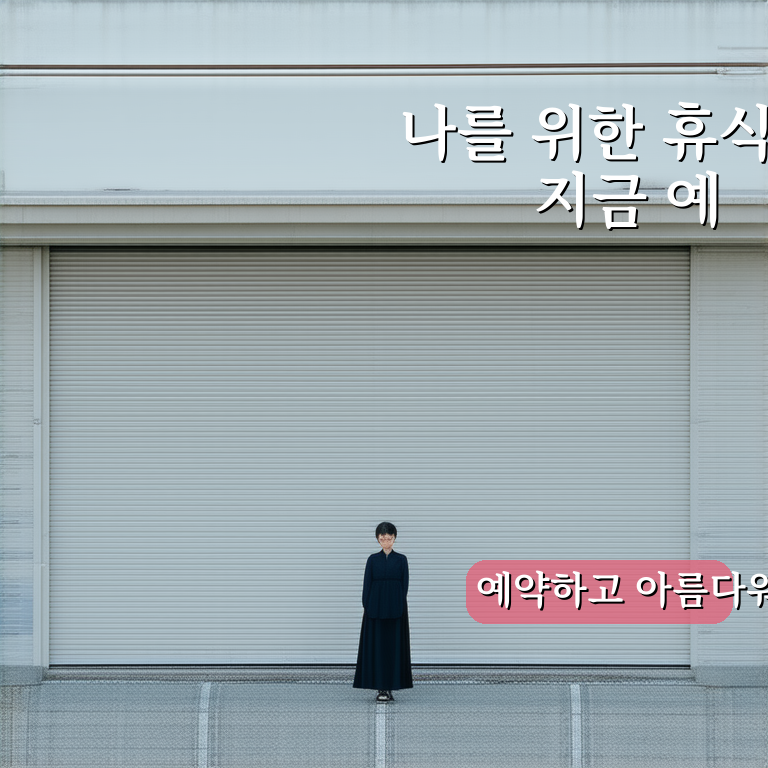

In [68]:
from IPython.display import Image, display
import glob, os

def show_image(name, kind='final'):
    """이미지 표시. name = 전체경로 | 파일명(final_composite.png 등) | job_id.
    kind: 'final'(최종 광고) | 'bg'(텍스트 없는 배경). job_id일 때만 적용."""
    name = (name or '').strip()
    img_root = os.path.join(RECORDS, 'images')
    cand = []
    if os.path.isfile(name):                                    # 1) 전체경로
        cand = [name]
    else:
        patt = 'final_composite*.png' if kind == 'final' else '*background*.png'
        job_dir = os.path.join(img_root, name)
        if os.path.isdir(job_dir):                              # 2) job_id 폴더
            cand = sorted(glob.glob(os.path.join(job_dir, patt))) or sorted(glob.glob(os.path.join(job_dir, '*.png')))
        if not cand:                                            # 3) 파일명(부분일치) 트리 검색
            cand = sorted(glob.glob(os.path.join(img_root, '**', name), recursive=True)) \
                or sorted(glob.glob(os.path.join(img_root, '**', '*' + name + '*'), recursive=True))
    if not cand:
        print('찾지 못함:', name, '| ', img_root, '아래에서 검색'); return
    for p in cand:
        print(p)
        display(Image(filename=p))

# 사용 예: show_image('test_cafe_iced_americano_20260608000015')  /  show_image('final_composite.png')  /  show_image(<job_id>, kind='bg')
show_image(q(OPS_DB, "SELECT job_id FROM jobs ORDER BY created_at DESC LIMIT 1")[0, 0])

/app/records/images/test_cafe_morning_set_20260608011644/final_composite.png


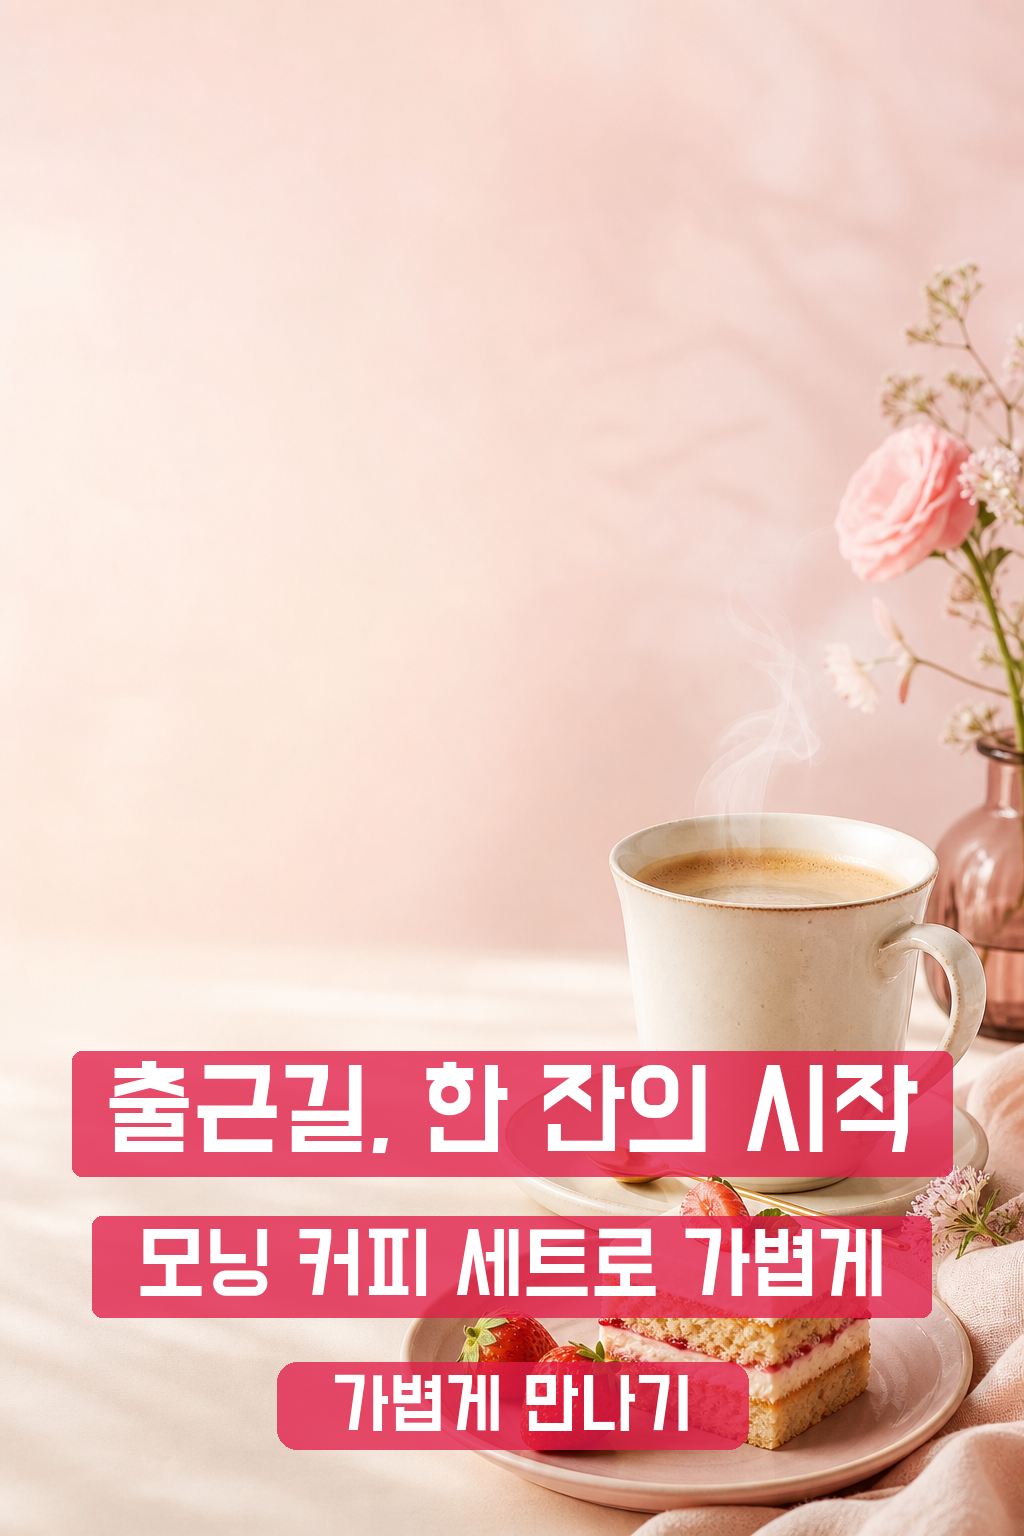

In [69]:
show_image('test_cafe_morning_set_20260608011644')